In [1]:

import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [2]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [3]:
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

In [4]:
# Base parameters for PMOS and NMOS
encoder_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "with_dummy": (False, False),
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False,
    "with_substrate_tap": False
}

In [5]:
pdk = gf180
encoder_comp = Component(name="encoder")
rules = encoder_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

# ----------------------------------------------------------------------
# 1. Component Instantiation
# ----------------------------------------------------------------------

# --- Differential Pair (M1, M2): Long channel L=10u, W=0.28u ---
xm1 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm2 = nmos(pdk, width=0.5, length=10.0, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult,**nmos_kwargs)

# --- Active Diode Loads (M3, M4): W=2u, L=0.28u ---
xm3 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm4 = pmos(pdk, width=2.0, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Output PMOS Current Mirrors (M5, M6, M7, M8): W=0.93u, L=1.86u ---
xm5 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm8 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm6 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
xm7 = pmos(pdk, width=0.93, length=1.86, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- Tail Current Source & Bias Network (M9, M10, M11): W=0.28u, L=0.28u ---
xm9  = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm10 = nmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
xm11 = pmos(pdk, width=0.5, length=0.28, fingers=1, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

2026-08-08 08:27:39.985 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [6]:
# ----------------------------------------------------------------------
# 2. Structural Placement & Floorplanning
# -----------------------------------------------------------------------

# Create references for all devices in the top component
xm1_ref  = encoder_comp << xm1
xm2_ref  = encoder_comp << xm2
xm3_ref  = encoder_comp << xm3
xm4_ref  = encoder_comp << xm4
xm5_ref  = encoder_comp << xm5
xm6_ref  = encoder_comp << xm6
xm7_ref  = encoder_comp << xm7
xm8_ref  = encoder_comp << xm8
xm9_ref  = encoder_comp << xm9
xm10_ref = encoder_comp << xm10
xm11_ref = encoder_comp << xm11


# Set instance names
xm1_ref.name  = "xm1"
xm2_ref.name  = "xm2"
xm3_ref.name  = "xm3"
xm4_ref.name  = "xm4"
xm5_ref.name  = "xm5"
xm6_ref.name  = "xm6"
xm7_ref.name  = "xm7"
xm8_ref.name  = "xm8"
xm9_ref.name  = "xm9"
xm10_ref.name = "xm10"
xm11_ref.name = "xm11"

#dynamic bbox
xm10_xy = evaluate_bbox(xm10)
xm9_xy  = evaluate_bbox(xm9)

xm1_xy  = evaluate_bbox(xm1)
xm2_xy  = evaluate_bbox(xm2)

xm8_xy  = evaluate_bbox(xm8)
xm5_xy  = evaluate_bbox(xm5)
xm3_xy  = evaluate_bbox(xm3)
xm11_xy = evaluate_bbox(xm11)
xm4_xy  = evaluate_bbox(xm4)
xm7_xy  = evaluate_bbox(xm7)
xm6_xy  = evaluate_bbox(xm6)

# Calculate Row Y-Coordinates dynamically to prevent Y-axis overlap
bottom_row_y = xm10_xy[1] / 2
middle_row_y = bottom_row_y + (xm10_xy[1] / 2) + spacing + (xm1_xy[1] / 2)
top_row_y    = middle_row_y + (xm1_xy[1] / 2) + spacing + (xm3_xy[1] / 2)

# --- BOTTOM ROW: Bias & Tail NMOS Array (xm10, xm9) ---
xm10_ref.move((0 + xm10_xy[0] / 2, bottom_row_y))
xm9_ref.move((xm10_ref.xmax + xm9_xy[0] / 2 + spacing, bottom_row_y))

# --- MIDDLE ROW: Differential Input NMOS Pair (xm1, xm2) ---
xm1_ref.move((0 + xm1_xy[0] / 2, middle_row_y))
xm2_ref.move((xm1_ref.xmax + xm2_xy[0] / 2 + spacing, middle_row_y))

# --- TOP ROW: PMOS Array (xm8, xm5, xm3, xm11, xm4, xm7, xm6) ---
xm8_ref.move((0 + xm8_xy[0] / 2, top_row_y))
xm5_ref.move((xm8_ref.xmax + xm5_xy[0] / 2 + spacing, top_row_y))
xm3_ref.move((xm5_ref.xmax + xm3_xy[0] / 2 + spacing, top_row_y))
xm11_ref.move((xm3_ref.xmax + xm11_xy[0] / 2 + spacing, top_row_y))
xm4_ref.move((xm11_ref.xmax + xm4_xy[0] / 2 + spacing, top_row_y))
xm7_ref.move((xm4_ref.xmax + xm7_xy[0] / 2 + spacing, top_row_y))
xm6_ref.move((xm7_ref.xmax + xm6_xy[0] / 2 + spacing, top_row_y))

ComponentReference (parent Component "Unnamed_7bc9c6c0", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_top_met_W', 'multiplier_0_plusdoped_W', 'multiplier_0_diff_W', 'multiplier_0_source_W', 'source_W', 'multiplier_0_drain_W', 'drain_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_N', 'multiplier_0_leftsd_array_row0_col0_bottom_via_N', 'multiplier_0_leftsd_array_row0_col0_bottom_met_N', 'multiplier_0_leftsd_array_row0_col0_top_met_N', 'mult

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 11 in 'encoder'
  gdspath = component.write_gds(
2026-08-08 08:27:55.502 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.2", "type": "reload", "file": "/tmp/gdsfactory/encoder.gds"}


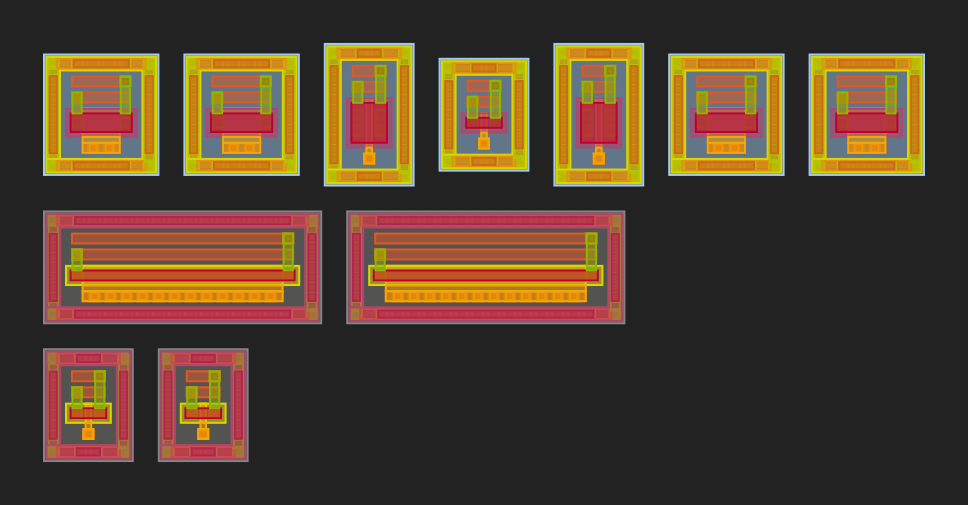

In [7]:
encoder_comp.show()
display_component(encoder_comp, scale = 2, path=".")

In [ ]:
# ----------------------------------------------------------------------
# 3. Interconnect Routing & Via Generation
# ----------------------------------------------------------------------

# # Helper to place a metal-to-metal via stack on a port
# def place_via_on_port(comp, port_name, via_type="via1"):
#     v = encoder_comp << via_stack(pdk, via_type)
#     v.move(comp.ports[port_name].center)
#     return v

# ----------------------------------------------------------------------
# 3. Interconnect Routing
# ----------------------------------------------------------------------
# Tail Node (a)
#encoder_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_source_E"], xm2_ref.ports["multiplier_0_source_W"])
encoder_comp << c_route(pdk, xm9_ref.ports["multiplier_0_drain_W"], xm1_ref.ports["multiplier_0_source_W"])

# --- B. Node 'x' Connections (M1 Drain, M3 Gate/Drain, M5 Gate, M8 Gate) ---
# Route M1 Drain to M3 Drain
# encoder_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_drain_N"], xm3_ref.ports["multiplier_0_drain_S"])
# encoder_comp << c_route(pdk, xm3_ref.ports["multiplier_0_gate_E"], xm3_ref.ports["multiplier_0_drain_E"])
# encoder_comp << straight_route(pdk, xm3_ref.ports["multiplier_0_gate_W"], xm5_ref.ports["multiplier_0_gate_E"])
# encoder_comp << straight_route(pdk, xm5_ref.ports["multiplier_0_gate_W"], xm8_ref.ports["multiplier_0_gate_E"])

# # --- C. Node 'y' Connections (M2 Drain, M4 Gate/Drain, M6 Gate, M7 Gate) ---
# # Route M2 Drain to M4 Drain
# encoder_comp << straight_route(pdk, xm2_ref.ports["multiplier_0_drain_N"], xm4_ref.ports["multiplier_0_drain_S"])
# # Tie M4 Gate to M4 Drain
# encoder_comp << c_route(pdk, xm4_ref.ports["multiplier_0_gate_W"], xm4_ref.ports["multiplier_0_drain_W"])
# # Bus node 'y' across M7 and M6 gates
# encoder_comp << straight_route(pdk, xm4_ref.ports["multiplier_0_gate_E"], xm7_ref.ports["multiplier_0_gate_W"])
# encoder_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_gate_E"], xm6_ref.ports["multiplier_0_gate_W"])

# # --- D. Bias Network (net1) Routing ---
# # Diode-connect M10 and M11
# encoder_comp << c_route(pdk, xm10_ref.ports["multiplier_0_gate_E"], xm10_ref.ports["multiplier_0_drain_E"])
# encoder_comp << straight_route(pdk, xm11_ref.ports["multiplier_0_gate_E"], xm11_ref.ports["multiplier_0_drain_E"])
# encoder_comp << straight_route(pdk, xm11_ref.ports["multiplier_0_drain_S"], xm10_ref.ports["multiplier_0_drain_N"])
# # Connect net1 (M10 gate) to M9 gate
# encoder_comp << straight_route(pdk, xm10_ref.ports["multiplier_0_gate_E"], xm9_ref.ports["multiplier_0_gate_W"])


# ----------------------------------------------------------------------
# 4. Global Power Rails (Vdd & Vss)
# ----------------------------------------------------------------------
# pmos_sources = [xm8_ref, xm5_ref, xm3_ref, xm11_ref, xm4_ref, xm7_ref, xm6_ref]
# for i in range(len(pmos_sources) - 1):
#     encoder_comp << straight_route(
#         pdk, 
#         pmos_sources[i].ports["multiplier_0_source_E"], 
#         pmos_sources[i+1].ports["multiplier_0_source_W"]
#     )

# encoder_comp << straight_route(pdk, xm10_ref.ports["multiplier_0_source_E"], xm9_ref.ports["multiplier_0_source_W"])


# ----------------------------------------------------------------------
# 5. Pin Exports for LVS
# ----------------------------------------------------------------------
# pin_mappings = {
#     "Vin":     xm1_ref.ports["multiplier_0_gate_W"],
#     "Vin_neg": xm2_ref.ports["multiplier_0_gate_E"],
#     "Iex_1_i": xm8_ref.ports["multiplier_0_drain_S"],
#     "Iex_2_i": xm5_ref.ports["multiplier_0_drain_S"],
#     "Iex_3_i": xm7_ref.ports["multiplier_0_drain_S"],
#     "Iex_4_i": xm6_ref.ports["multiplier_0_drain_S"],
#     "Vdd":     xm8_ref.ports["multiplier_0_source_W"],
#     "Vss":     xm10_ref.ports["multiplier_0_source_W"],
# }

# for pin_name, source_port in pin_mappings.items():
#     encoder_comp.add_port(name=pin_name, port=source_port)
#     encoder_comp.add_label(
#         text=pin_name,
#         position=source_port.center,
#         layer=pdk.get_glayer("met2"),
#     )

#encoder_comp.write_gds("encoder_layout.gds")

ValueError: Ports must be parralel and have same orientation

2026-08-08 08:28:04.692 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.2", "type": "reload", "file": "/tmp/gdsfactory/encoder.gds"}


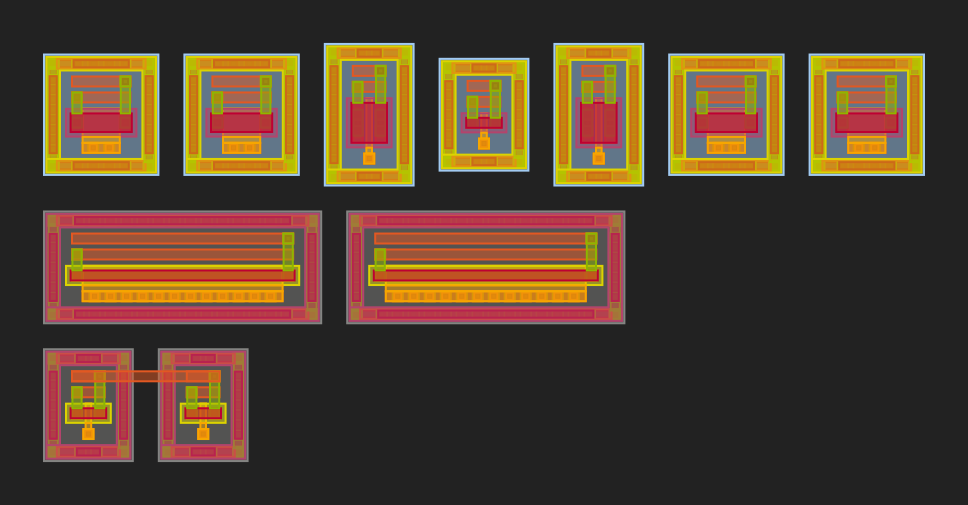

In [9]:
encoder_comp.show()
display_component(encoder_comp, scale=2, path=".")

In [12]:
encoder_comp.name="encoder_drc"
drc_result = gf180.drc_magic(encoder_comp, encoder_comp.name)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:495: UserWarning: Unnamed cells, 11 in 'encoder_drc'
  layout.write_gds(gds_path)
2026-08-08 08:24:23.942 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmprs21scmp/encoder_drc.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 528 - Compiled on Wed Jun 18 09:45:25 PM CEST 2025.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmprs21scmp/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "encoder_drc".
Reading "Unnamed_596ca54a".
Reading "Unnamed_7a4118dd"

In [5]:
'''
.subckt encoder Vdd Vss Vin Vin_neg Iex_1_i Iex_2_i Iex_3_i Iex_4_i
*.PININFO Vdd:B Vss:B Vin:I Vin_neg:I Iex_1_i:O Iex_4_i:O Iex_2_i:O Iex_3_i:O
XM1 x Vin a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM2 y Vin_neg a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM3 x x Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM4 y y Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM5 Iex_2_i x Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM7 Iex_3_i y Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM9 a net1 Vss Vss nfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM10 net1 net1 Vss Vss nfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM11 net1 net1 Vdd Vdd pfet_03v3 L=0.28u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM6 Iex_4_i y Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
XM8 Iex_1_i x Vdd Vdd pfet_03v3 L=1.86u W=0.93u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1
.ends
'''

"\n.subckt encoder Vdd Vss Vin Vin_neg Iex_1_i Iex_2_i Iex_3_i Iex_4_i\n*.PININFO Vdd:B Vss:B Vin:I Vin_neg:I Iex_1_i:O Iex_4_i:O Iex_2_i:O Iex_3_i:O\nXM1 x Vin a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'\n+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1\nXM2 y Vin_neg a Vss nfet_03v3 L=10u W=0.28u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'\n+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1\nXM3 x x Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'\n+ ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0 m=1\nXM4 y y Vdd Vdd pfet_03v3 L=0.28u W=2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd